In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/processed/campaign_data_cleaned.csv")
df.head()


,campaign_id,campaign_type,target_audience,duration,channel_used,impressions,clicks,leads,conversions,revenue,acquisition_cost,roi,language,engagement_score,customer_segment,date,CTR,Conversion_Rate,CPL,CPCV
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,2025-04-29,0.106498,0.382554,0.030705,0.047146
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,2025-04-06,0.036176,0.408612,0.091745,0.133257
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,2025-01-14,0.140448,0.346013,0.095168,0.120000
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,2025-06-04,0.095479,0.112564,0.111641,0.263010
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29,0.038639,0.336094,0.110971,0.181717


In [3]:
df["date"] = pd.to_datetime(df["date"])


In [6]:
#Compute Frequency per Customer Segment
freq_df = df.groupby("customer_segment").agg({
    "campaign_id": "count"
}).reset_index()

freq_df.columns = ["customer_segment", "frequency"]
freq_df.head()


,customer_segment,frequency
0,College Students,33533
1,Premium Shoppers,33071
2,Tier 2 City Customers,33091
3,Working Women,33413
4,Youth,33557


In [7]:
df = df.merge(freq_df, on="customer_segment", how="left")


In [14]:
#Define churn rule
df["churn"] = np.where(
    (df["engagement_score"] < 30) |
    (df["Conversion_Rate"] < 0.02) |
    (df["frequency"] <= 2),
    1, 0
)

df["churn"].value_counts()


churn
1    166629
0        36
Name: count, dtype: int64

Feature Engineering

In [19]:
#Select features
features = [
    "impressions", "clicks", "leads", "conversions", "revenue",
    "acquisition_cost", "roi", "engagement_score", "CTR",
    "Conversion_Rate", "CPL", "CPCV", "frequency",
    "campaign_type", "channel_used", "customer_segment", "language"
]

X = df[features]
y = df["churn"]


In [20]:
#Identify numeric & categorical columns
numeric_features = [
    "impressions", "clicks", "leads", "conversions", "revenue",
    "acquisition_cost", "roi", "engagement_score", "CTR",
    "Conversion_Rate", "CPL", "CPCV", "frequency"
]

categorical_features = [
    "campaign_type", "channel_used", "customer_segment", "language"
]


In [21]:
#Preprocessing pipeline
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


Logistic Regression Model

In [23]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])


In [24]:
log_reg_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['impressions','clicks','leads',...,'channel_used','customer_segment', 'language']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

Accuracy: 0.9997840017279862
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       1.00      1.00      1.00     41658

    accuracy                           1.00     41667
   macro avg       0.50      0.50      0.50     41667
weighted avg       1.00      1.00      1.00     41667



c:\Users\abdul\micromamba\envs\cpu\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abdul\micromamba\envs\cpu\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abdul\micromamba\envs\cpu\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

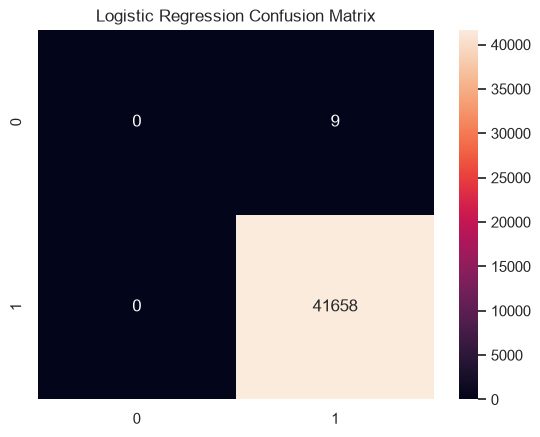

In [26]:
#Evaluate
y_pred_lr = log_reg_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


Random Forest Model

In [27]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ))
])


In [28]:
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['impressions','clicks','leads',...,'channel_used','customer_segment', 'language']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

Accuracy: 0.9998560011519908
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         9
           1       1.00      1.00      1.00     41658

    accuracy                           1.00     41667
   macro avg       1.00      0.67      0.75     41667
weighted avg       1.00      1.00      1.00     41667



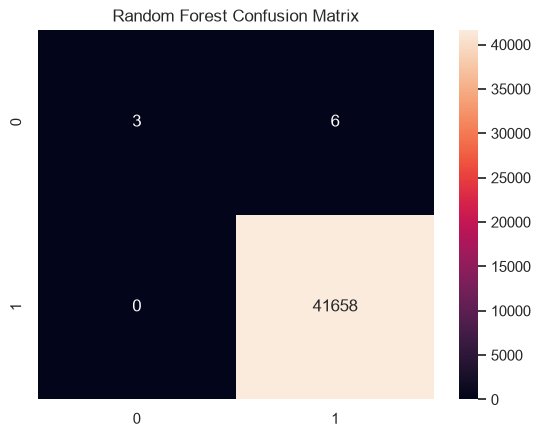

In [29]:
#Evaluate RF
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()


Extract feature importance

In [ ]:

rf = rf_model.named_steps["classifier"]
ohe = rf_model.named_steps["preprocessor"].named_transformers_["cat"]

cat_names = ohe.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_names)

importances = pd.DataFrame({
    "Feature": all_features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importances.head(15)


,Feature,Importance
7,engagement_score,0.444803
9,Conversion_Rate,0.091008
8,CTR,0.073538
3,conversions,0.049005
0,impressions,0.045122
1,clicks,0.031701
4,revenue,0.031361
10,CPL,0.030978
5,acquisition_cost,0.030236
11,CPCV,0.028228


Export churn predictions

In [31]:
#Add predictions to dataset
df["Churn_Prediction"] = rf_model.predict(X)
df.to_csv("../data/processed/churn_predictions.csv", index=False)


In [32]:
#Save model
import joblib
joblib.dump(rf_model, "../models/churn_model.pkl")


['../models/churn_model.pkl']

No Recency dependency

Behavior‑based churn definition

Frequency‑based churn logic

Clean ML pipeline

Exported churn predictions